In [14]:
# Cell 1: Load project inputs and select the UTM zone covering the largest share of the AOI.
import json
from pathlib import Path

import geopandas as gpd
import numpy as np
import rasterio
from pyproj import Geod
from rasterio.warp import Resampling, calculate_default_transform, reproject
from rasterio.windows import Window
from shapely.geometry import box, shape
from shapely.ops import unary_union

cwd = Path.cwd()
project_dir = cwd.parent if cwd.name.lower() in {"notebook", "notebooks"} else cwd
input_dir = project_dir / "data"
results_dir = project_dir / "results"
preprocessing_dir = results_dir / "preprocessing"
output_dir = preprocessing_dir
preprocessing_dir.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)

source_dem_path = input_dir / "sourceDEM.tif"
aoi_path = input_dir / "watershedAOI.geojson"
outlet_path = input_dir / "outlet.shp"
for required_path in (source_dem_path, aoi_path, outlet_path):
    if not required_path.exists():
        raise FileNotFoundError(f"Required input is missing: {required_path}")

aoi_doc = json.loads(aoi_path.read_text(encoding="utf-8"))
aoi_features = aoi_doc.get("features", [])
if len(aoi_features) != 1:
    raise ValueError("watershedAOI.geojson must contain exactly one rectangle.")
aoi_geometry = shape(aoi_features[0]["geometry"])
if aoi_geometry.geom_type not in ("Polygon", "MultiPolygon") or not aoi_geometry.is_valid:
    raise ValueError("The AOI must be a valid rectangular polygon.")
min_lon, min_lat, max_lon, max_lat = aoi_geometry.bounds
if min_lat < -80 or max_lat > 84:
    raise ValueError("UTM is defined between 80 degrees south and 84 degrees north; redraw the AOI within that range.")
if max_lon - min_lon > 180:
    raise ValueError("The AOI crosses the antimeridian or spans over 180 degrees; choose a smaller UTM-compatible rectangle.")

geod = Geod(ellps="WGS84")
zone_geometries = {zone: [box(-180 + (zone - 1) * 6, -80, -180 + zone * 6, 84)] for zone in range(1, 61)}
# Apply the standard Norway and Svalbard UTM zone exceptions.
zone_geometries[31].append(box(6, 72, 9, 84))
zone_geometries[32].append(box(3, 56, 6, 64))
zone_geometries[33].extend((box(9, 72, 12, 84), box(18, 72, 21, 84)))
zone_geometries[34].append(box(18, 72, 24, 84))
zone_geometries[35].extend((box(21, 72, 24, 84), box(30, 72, 33, 84)))
zone_geometries[36].append(box(30, 72, 36, 84))
zone_geometries[37].append(box(33, 72, 36, 84))
zone_geometries[31][0] = zone_geometries[31][0].difference(box(3, 56, 6, 64))
zone_geometries[32][0] = zone_geometries[32][0].difference(box(6, 72, 12, 84))
zone_geometries[34][0] = zone_geometries[34][0].difference(box(18, 72, 24, 84))
zone_geometries[36][0] = zone_geometries[36][0].difference(box(30, 72, 36, 84))

zone_areas = {}
for zone, regions in zone_geometries.items():
    intersection = aoi_geometry.intersection(unary_union(regions))
    if intersection.is_empty:
        continue
    area_m2, _ = geod.geometry_area_perimeter(intersection)
    if area_m2:
        zone_areas[zone] = abs(area_m2)
if not zone_areas:
    raise ValueError("Could not determine a UTM zone for the selected AOI.")

utm_zone = max(zone_areas, key=zone_areas.get)
hemisphere_areas = {}
for north, south_box in ((True, box(-180, 0, 180, 84)), (False, box(-180, -80, 180, 0))):
    area_m2, _ = geod.geometry_area_perimeter(aoi_geometry.intersection(unary_union(zone_geometries[utm_zone]).intersection(south_box)))
    hemisphere_areas[north] = abs(area_m2)
northern_hemisphere = max(hemisphere_areas, key=hemisphere_areas.get)
utm_epsg = (32600 if northern_hemisphere else 32700) + utm_zone
dst_crs = f"EPSG:{utm_epsg}"
print(f"Selected UTM zone {utm_zone}{'N' if northern_hemisphere else 'S'} ({dst_crs}), based on the largest AOI area in that zone.")

Selected UTM zone 44N (EPSG:32644), based on the largest AOI area in that zone.


In [15]:
# Cell 2: Project the DEM and trim equal strips from all sides to make a NoData-free rectangle.
projected_dem_path = preprocessing_dir / "projectedDEM.tif"
rectangular_dem_path = preprocessing_dir / "rectangularDEM.tif"
dst_nodata = -9999.0

with rasterio.open(source_dem_path) as src:
    if src.crs is None:
        raise ValueError("The source DEM has no CRS; cannot select or apply a UTM projection.")
    transform, width, height = calculate_default_transform(
        src.crs,
        dst_crs,
        src.width,
        src.height,
        *src.bounds,
        resolution=30,
    )
    profile = src.profile.copy()
    profile.update(
        driver="GTiff",
        height=height,
        width=width,
        count=1,
        dtype="float32",
        crs=dst_crs,
        transform=transform,
        nodata=dst_nodata,
        compress="lzw",
        tiled=True,
        blockxsize=256,
        blockysize=256,
    )
    with rasterio.open(projected_dem_path, "w", **profile) as dst:
        reproject(
            source=rasterio.band(src, 1),
            destination=rasterio.band(dst, 1),
            src_transform=src.transform,
            src_crs=src.crs,
            src_nodata=src.nodata,
            dst_transform=transform,
            dst_crs=dst_crs,
            dst_nodata=dst_nodata,
            resampling=Resampling.bilinear,
        )

with rasterio.open(projected_dem_path) as src:
    if min(src.width, src.height) < 3:
        raise ValueError("The projected DEM is too small to trim into a usable rectangle.")

    def is_nodata_free(row_start, col_start, row_stop, col_stop):
        for row in range(row_start, row_stop, 512):
            for col in range(col_start, col_stop, 512):
                window = Window(
                    col,
                    row,
                    min(512, col_stop - col),
                    min(512, row_stop - row),
                )
                values = src.read(1, window=window)
                valid = (src.read_masks(1, window=window) > 0) & np.isfinite(values)
                if src.nodata is not None:
                    valid &= values != src.nodata
                if not valid.all():
                    return False
        return True

    max_margin = (min(src.width, src.height) - 3) // 2
    if not is_nodata_free(max_margin, max_margin, src.height - max_margin, src.width - max_margin):
        raise ValueError(
            "NoData remains inside the largest centered rectangle after trimming its outer strips. "
            "Choose an AOI with a wider buffer or inspect the source DEM; interior NoData cannot be removed by edge trimming."
        )

    low_margin, high_margin = 0, max_margin
    while low_margin < high_margin:
        margin = (low_margin + high_margin) // 2
        if is_nodata_free(margin, margin, src.height - margin, src.width - margin):
            high_margin = margin
        else:
            low_margin = margin + 1

    strip_width = low_margin
    row_start = col_start = strip_width
    row_stop, col_stop = src.height - strip_width, src.width - strip_width
    crop_width, crop_height = col_stop - col_start, row_stop - row_start
    out_profile = src.profile.copy()
    out_profile.update(
        height=crop_height,
        width=crop_width,
        transform=src.window_transform(Window(col_start, row_start, crop_width, crop_height)),
        nodata=None,
        compress="lzw",
    )
    with rasterio.open(rectangular_dem_path, "w", **out_profile) as dst:
        for row in range(row_start, row_stop, 512):
            for col in range(col_start, col_stop, 512):
                window = Window(
                    col,
                    row,
                    min(512, col_stop - col),
                    min(512, row_stop - row),
                )
                values = src.read(1, window=window)
                valid = (src.read_masks(1, window=window) > 0) & np.isfinite(values)
                if src.nodata is not None:
                    valid &= values != src.nodata
                if not valid.all():
                    raise ValueError("NoData was found during final DEM writing; the output was not completed.")
                dst.write(values, 1, window=Window(col - col_start, row - row_start, window.width, window.height))
with rasterio.open(rectangular_dem_path) as src:
    print(f"NoData-free projected DEM saved: {rectangular_dem_path}")
    print("Projection :", src.crs)
    print("Dimensions :", src.width, "x", src.height)
    print("Resolution :", src.res)
    print("Bounds     :", src.bounds)
    print("NoData tag :", src.nodata)

NoData-free projected DEM saved: d:\HydropowerScreening\results\preprocessing\rectangularDEM.tif
Projection : EPSG:32644
Dimensions : 6140 x 7100
Resolution : (30.0, 30.0)
Bounds     : BoundingBox(left=683959.9370423305, bottom=3050745.549639882, right=868159.9370423305, top=3263745.549639882)
NoData tag : None


In [16]:
# Cell 3: Fill DEM depressions before calculating drainage.
from whitebox.whitebox_tools import WhiteboxTools

wbt = WhiteboxTools()
wbt.set_working_dir(str(preprocessing_dir))
filled_dem_path = preprocessing_dir / "filledDEM.tif"
if filled_dem_path.exists():
    filled_dem_path.unlink()

status = wbt.fill_depressions(dem=str(rectangular_dem_path), output=str(filled_dem_path))
if status != 0 or not filled_dem_path.exists():
    raise RuntimeError("WhiteboxTools failed to create the depression-filled DEM.")
print(f"Filled DEM saved: {filled_dem_path}")

.\whitebox_tools.exe --run="FillDepressions" --wd="d:\HydropowerScreening\results\preprocessing" --dem='d:\HydropowerScreening\results\preprocessing\rectangularDEM.tif' --output='d:\HydropowerScreening\results\preprocessing\filledDEM.tif' --fix_flats -v --compress_rasters=False

******************************
* Welcome to FillDepressions *
* Powered by WhiteboxTools   *
* www.whiteboxgeo.com        *
******************************
Reading data...
Finding pit cells: 5%
Finding pit cells: 10%
Finding pit cells: 15%
Finding pit cells: 20%
Finding pit cells: 25%
Finding pit cells: 30%
Finding pit cells: 35%
Finding pit cells: 40%
Finding pit cells: 45%
Finding pit cells: 50%
Finding pit cells: 55%
Finding pit cells: 60%
Finding pit cells: 65%
Finding pit cells: 70%
Finding pit cells: 75%
Finding pit cells: 80%
Finding pit cells: 85%
Finding pit cells: 90%
Finding pit cells: 95%
Finding pit cells: 100%
Filling depressions: 0%
Filling depressions: 1%
Filling depressions: 2%
Filling depressio

In [17]:
# Cell 4: Calculate the D8 flow pointer and accumulation from the pointer raster.
flow_pointer_path = preprocessing_dir / "flowPointer.tif"
flow_accumulation_path = preprocessing_dir / "flowAccumulation.tif"
for output_path in (flow_pointer_path, flow_accumulation_path):
    if output_path.exists():
        output_path.unlink()

status = wbt.d8_pointer(dem=str(filled_dem_path), output=str(flow_pointer_path))
if status != 0 or not flow_pointer_path.exists():
    raise RuntimeError("WhiteboxTools failed to create the D8 flow-pointer raster.")
status = wbt.d8_flow_accumulation(
    i=str(flow_pointer_path),
    output=str(flow_accumulation_path),
    out_type="cells",
    pntr=True,
)
if status != 0 or not flow_accumulation_path.exists():
    raise RuntimeError("WhiteboxTools failed to create the D8 flow-accumulation raster.")
print(f"D8 flow pointer: {flow_pointer_path}")
print(f"D8 flow accumulation: {flow_accumulation_path}")

.\whitebox_tools.exe --run="D8Pointer" --wd="d:\HydropowerScreening\results\preprocessing" --dem='d:\HydropowerScreening\results\preprocessing\filledDEM.tif' --output='d:\HydropowerScreening\results\preprocessing\flowPointer.tif' -v --compress_rasters=False

****************************
* Welcome to D8Pointer     *
* Powered by WhiteboxTools *
* www.whiteboxgeo.com      *
****************************
Reading data...
Progress: 0%
Progress: 1%
Progress: 2%
Progress: 3%
Progress: 4%
Progress: 5%
Progress: 6%
Progress: 7%
Progress: 8%
Progress: 9%
Progress: 10%
Progress: 11%
Progress: 12%
Progress: 13%
Progress: 14%
Progress: 15%
Progress: 16%
Progress: 17%
Progress: 18%
Progress: 19%
Progress: 20%
Progress: 21%
Progress: 22%
Progress: 23%
Progress: 24%
Progress: 25%
Progress: 26%
Progress: 27%
Progress: 28%
Progress: 29%
Progress: 30%
Progress: 31%
Progress: 32%
Progress: 33%
Progress: 34%
Progress: 35%
Progress: 36%
Progress: 37%
Progress: 38%
Progress: 39%
Progress: 40%
Progress: 41%
Pr

In [18]:
# Cell 5: Reproject the outlet and snap it to the highest-accumulation cell within the search radius.
import geopandas as gpd
from shapely.geometry import Point

outlet_utm_path = preprocessing_dir / "outlet_utm.shp"
snapped_outlet_path = preprocessing_dir / "outlet_snapped.shp"
outlet_gdf = gpd.read_file(outlet_path)
if len(outlet_gdf) != 1 or outlet_gdf.geometry.iloc[0].geom_type != "Point":
    raise ValueError("outlet.shp must contain exactly one point.")
if outlet_gdf.crs is None:
    raise ValueError("outlet.shp has no CRS; it must be saved in EPSG:4326.")
outlet_utm = outlet_gdf.to_crs(dst_crs)
with rasterio.open(rectangular_dem_path) as src:
    bounds = src.bounds
    point = outlet_utm.geometry.iloc[0]
    if not (bounds.left <= point.x <= bounds.right and bounds.bottom <= point.y <= bounds.top):
        raise ValueError("The outlet falls outside the trimmed DEM. Redraw a larger AOI around both the outlet and the full catchment.")
    snap_distance_cells = 10
    snap_distance = snap_distance_cells * max(src.res)

outlet_utm.to_file(outlet_utm_path)
for old_file in preprocessing_dir.glob(f"{snapped_outlet_path.stem}.*"):
    old_file.unlink()
status = wbt.snap_pour_points(
    pour_pts=str(outlet_utm_path),
    flow_accum=str(flow_accumulation_path),
    output=str(snapped_outlet_path),
    snap_dist=snap_distance,
)
if status != 0 or not snapped_outlet_path.exists():
    raise RuntimeError("WhiteboxTools failed to snap the outlet to a nearby flow-accumulation cell.")
snapped_outlet = gpd.read_file(snapped_outlet_path)
if len(snapped_outlet) != 1 or snapped_outlet.geometry.iloc[0].geom_type != "Point":
    raise ValueError("The snapped outlet file does not contain exactly one point.")
movement = point.distance(snapped_outlet.geometry.iloc[0])
if movement > snap_distance + 1e-6:
    raise ValueError(f"The snapped outlet moved {movement:.1f} m, beyond the {snap_distance:.1f} m search radius.")
print(f"Outlet reprojected to {dst_crs}: {outlet_utm_path}")
print(f"Snapped outlet: {snapped_outlet_path}")
print(f"Snap search radius: {snap_distance:.0f} m ({snap_distance_cells} DEM cells); actual movement: {movement:.1f} m")

.\whitebox_tools.exe --run="SnapPourPoints" --wd="d:\HydropowerScreening\results\preprocessing" --pour_pts='d:\HydropowerScreening\results\preprocessing\outlet_utm.shp' --flow_accum='d:\HydropowerScreening\results\preprocessing\flowAccumulation.tif' --output='d:\HydropowerScreening\results\preprocessing\outlet_snapped.shp' --snap_dist='300.0' -v --compress_rasters=False

*****************************
* Welcome to SnapPourPoints *
* Powered by WhiteboxTools  *
* www.whiteboxgeo.com       *
*****************************
Reading data...
Progress: 0%
Saving data...
Output file written
Elapsed Time (excluding I/O): 0.0s
Outlet reprojected to EPSG:32644: d:\HydropowerScreening\results\preprocessing\outlet_utm.shp
Snapped outlet: d:\HydropowerScreening\results\preprocessing\outlet_snapped.shp
Snap search radius: 300 m (10 DEM cells); actual movement: 170.3 m


In [19]:
# Cell 6: Delineate the snapped outlet catchment, save its boundary, and mask the DEM to that basin.
from rasterio.features import shapes

watershed_raster_path = preprocessing_dir / "watershed.tif"
watershed_boundary_path = output_dir / "watershedBoundary.shp"
watershed_mask_path = preprocessing_dir / "watershed_mask.tif"
watershed_dem_path = output_dir / "watershedDEM.tif"
partial_watershed_dem_path = preprocessing_dir / "watershedDEM.partial.tif"

if watershed_raster_path.exists():
    watershed_raster_path.unlink()
status = wbt.watershed(
    d8_pntr=str(flow_pointer_path),
    pour_pts=str(snapped_outlet_path),
    output=str(watershed_raster_path),
)
if status != 0 or not watershed_raster_path.exists():
    raise RuntimeError("WhiteboxTools failed to delineate the watershed from the snapped outlet.")

basin_bounds = None
basin_id = None
with rasterio.open(watershed_raster_path) as watershed_src:
    watershed_crs = watershed_src.crs
    if watershed_crs is None:
        raise ValueError("The watershed raster has no CRS.")
    mask_profile = {
        "driver": "GTiff",
        "height": watershed_src.height,
        "width": watershed_src.width,
        "count": 1,
        "dtype": "uint8",
        "crs": watershed_crs,
        "transform": watershed_src.transform,
        "nodata": 0,
        "compress": "deflate",
        "tiled": True,
    }
    with rasterio.open(watershed_mask_path, "w", **mask_profile) as mask_dst:
        for row_off in range(0, watershed_src.height, 512):
            height = min(512, watershed_src.height - row_off)
            for col_off in range(0, watershed_src.width, 512):
                width = min(512, watershed_src.width - col_off)
                window = Window(col_off, row_off, width, height)
                watershed_tile = watershed_src.read(1, window=window)
                valid = np.isfinite(watershed_tile) & (watershed_tile > 0)
                if watershed_src.nodata is not None:
                    valid &= watershed_tile != watershed_src.nodata
                if valid.any():
                    rows, cols = np.nonzero(valid)
                    tile_bounds = (
                        row_off + int(rows.min()),
                        row_off + int(rows.max()) + 1,
                        col_off + int(cols.min()),
                        col_off + int(cols.max()) + 1,
                    )
                    if basin_bounds is None:
                        basin_bounds = tile_bounds
                        basin_id = int(watershed_tile[valid].max())
                    else:
                        basin_bounds = (
                            min(basin_bounds[0], tile_bounds[0]),
                            max(basin_bounds[1], tile_bounds[1]),
                            min(basin_bounds[2], tile_bounds[2]),
                            max(basin_bounds[3], tile_bounds[3]),
                        )
                        basin_id = max(basin_id, int(watershed_tile[valid].max()))
                mask_dst.write(valid.astype("uint8"), 1, window=window)

if basin_bounds is None:
    raise ValueError("No watershed cells were delineated. Check the snapped outlet and D8 flow pointer.")
row_start, row_stop, col_start, col_stop = basin_bounds
print(f"Watershed cells found; raster bounds: rows {row_start}:{row_stop}, columns {col_start}:{col_stop}.")

with rasterio.open(watershed_raster_path) as watershed_src, rasterio.open(watershed_mask_path) as mask_src:
    watershed_features = [
        shape(geometry)
        for geometry, value in shapes(
            rasterio.band(watershed_src, 1),
            mask=rasterio.band(mask_src, 1),
            transform=watershed_src.transform,
        )
        if value > 0
    ]
    if not watershed_features:
        raise ValueError("Polygonization produced no watershed boundary features.")
    watershed_feature_count = len(watershed_features)
    watershed_geometry = watershed_features[0] if len(watershed_features) == 1 else unary_union(watershed_features)
    del watershed_features
    watershed_crs = watershed_src.crs
print(f"Polygonized {watershed_feature_count} connected watershed feature(s) from raster bands.")

watershed_gdf = gpd.GeoDataFrame(
    {"ws_id": [basin_id]},
    geometry=[watershed_geometry],
    crs=watershed_crs,
)
watershed_gdf["name"] = "watershed"
watershed_gdf["area_km2"] = watershed_gdf.geometry.area / 1_000_000
for old_file in output_dir.glob(f"{watershed_boundary_path.stem}.*"):
    old_file.unlink()
watershed_gdf.to_file(watershed_boundary_path)

with rasterio.open(rectangular_dem_path) as dem_src, rasterio.open(watershed_mask_path) as mask_src:
    if (
        dem_src.crs != watershed_crs
        or dem_src.width != mask_src.width
        or dem_src.height != mask_src.height
    ):
        raise ValueError("The watershed raster does not align with the projected DEM.")
    crop = Window(
        col_start,
        row_start,
        col_stop - col_start,
        row_stop - row_start,
    )
    clipped_profile = dem_src.profile.copy()
    clipped_profile.update(
        height=int(crop.height),
        width=int(crop.width),
        transform=dem_src.window_transform(crop),
        dtype="float32",
        nodata=-9999.0,
        compress="lzw",
    )
    if partial_watershed_dem_path.exists():
        partial_watershed_dem_path.unlink()
    with rasterio.open(partial_watershed_dem_path, "w", **clipped_profile) as dem_dst:
        for row_off in range(0, int(crop.height), 512):
            height = min(512, int(crop.height) - row_off)
            for col_off in range(0, int(crop.width), 512):
                width = min(512, int(crop.width) - col_off)
                source_window = Window(
                    col_start + col_off,
                    row_start + row_off,
                    width,
                    height,
                )
                output_window = Window(col_off, row_off, width, height)
                clipped_tile = dem_src.read(1, window=source_window).astype("float32", copy=True)
                basin_tile = mask_src.read(1, window=source_window) > 0
                clipped_tile[~basin_tile] = -9999.0
                dem_dst.write(clipped_tile, 1, window=output_window)

partial_watershed_dem_path.replace(watershed_dem_path)
watershed_mask_path.unlink()

print(f"Delineated watershed boundary saved: {watershed_boundary_path}")
print(f"DEM clipped to this outlet's watershed: {watershed_dem_path}")
print(watershed_gdf[["ws_id", "area_km2"]])

.\whitebox_tools.exe --run="Watershed" --wd="d:\HydropowerScreening\results\preprocessing" --d8_pntr='d:\HydropowerScreening\results\preprocessing\flowPointer.tif' --pour_pts='d:\HydropowerScreening\results\preprocessing\outlet_snapped.shp' --output='d:\HydropowerScreening\results\preprocessing\watershed.tif' -v --compress_rasters=False

****************************
* Welcome to Watershed     *
* Powered by WhiteboxTools *
* www.whiteboxgeo.com      *
****************************
Reading data...
Locating pour points: 0%
Initializing: 1%
Initializing: 2%
Initializing: 3%
Initializing: 4%
Initializing: 5%
Initializing: 6%
Initializing: 7%
Initializing: 8%
Initializing: 9%
Initializing: 10%
Initializing: 11%
Initializing: 12%
Initializing: 13%
Initializing: 14%
Initializing: 15%
Initializing: 16%
Initializing: 17%
Initializing: 18%
Initializing: 19%
Initializing: 20%
Initializing: 21%
Initializing: 22%
Initializing: 23%
Initializing: 24%
Initializing: 25%
Initializing: 26%
Initializing: 2

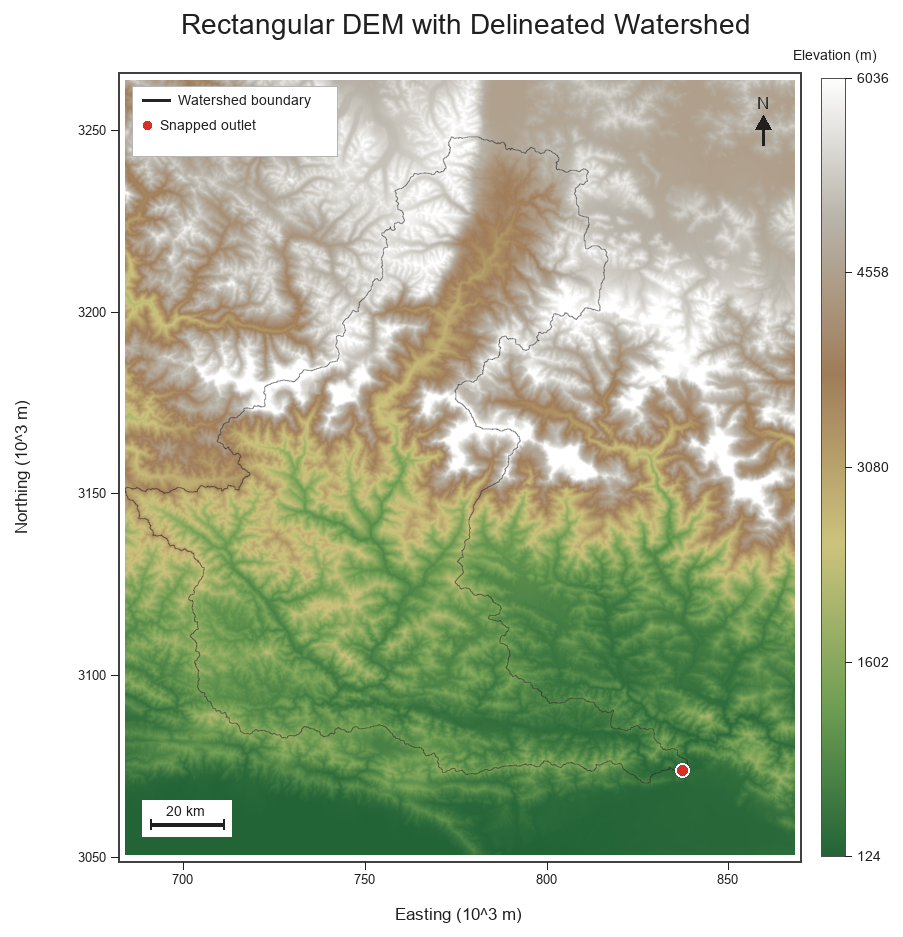

Rectangular DEM with watershed boundary saved: d:\HydropowerScreening\results\preprocessing\watershedDEM_with_boundary.png


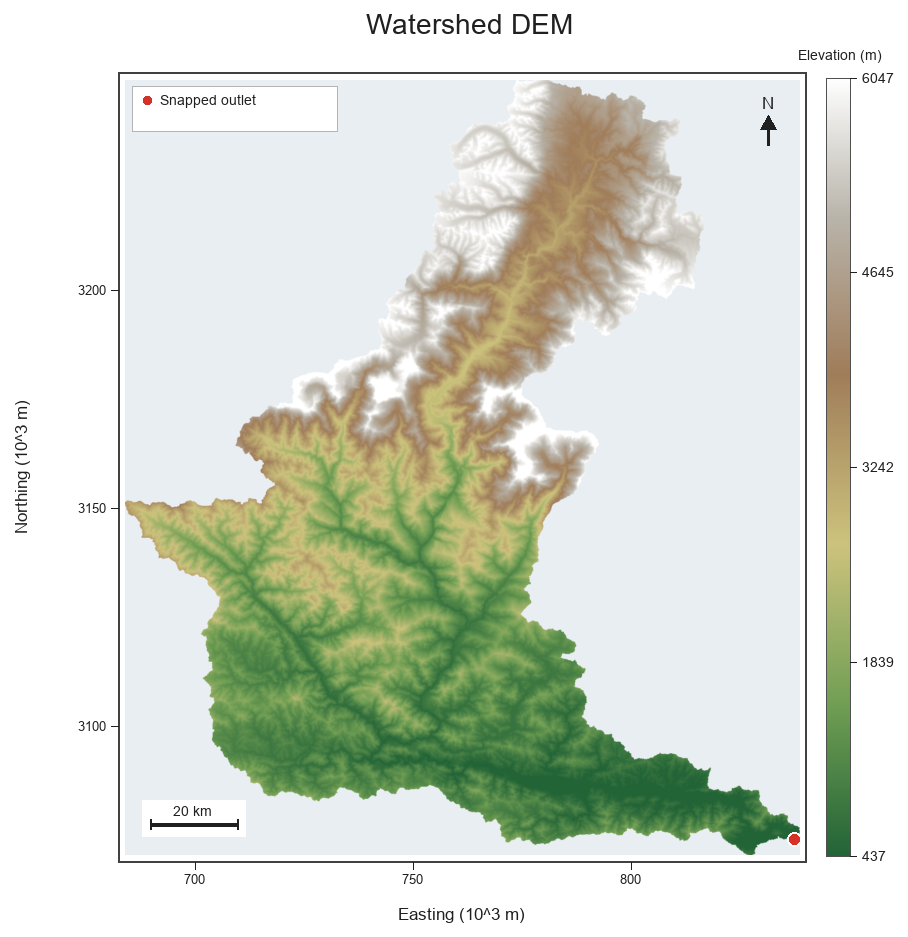

Watershed-only DEM colour-ramp image saved: d:\HydropowerScreening\results\preprocessing\watershedDEM.png


In [20]:
# Cell 7: Save and display the rectangular and watershed-only DEM maps.
import importlib
import sys
from IPython.display import Image, display

notebook_dir = project_dir / "notebook"
if str(notebook_dir) not in sys.path:
    sys.path.insert(0, str(notebook_dir))
import helper
helper = importlib.reload(helper)

rectangular_png_path = output_dir / "watershedDEM_with_boundary.png"
helper.plot_dem(
    rectangular_dem_path,
    rectangular_png_path,
    "Rectangular DEM with Delineated Watershed",
    snapped_outlet_path,
    watershed_boundary=watershed_gdf,
)
display(Image(filename=str(rectangular_png_path)))
print(f"Rectangular DEM with watershed boundary saved: {rectangular_png_path}")

png_path = output_dir / "watershedDEM.png"
helper.plot_dem(
    watershed_dem_path,
    png_path,
    "Watershed DEM",
    snapped_outlet_path,
)
display(Image(filename=str(png_path)))
print(f"Watershed-only DEM colour-ramp image saved: {png_path}")

In [21]:
# Cell 8: List the final watershed deliverables and supporting preprocessing files.
print("Final watershed deliverables:")
for path in (watershed_dem_path, watershed_boundary_path, png_path):
    if path.exists():
        print(f"  {path} ({path.stat().st_size / (1024 * 1024):.2f} MB)")
print("Preprocessing directory:", preprocessing_dir.resolve())

Final watershed deliverables:
  d:\HydropowerScreening\results\preprocessing\watershedDEM.tif (53.40 MB)
  d:\HydropowerScreening\results\preprocessing\watershedBoundary.shp (0.31 MB)
  d:\HydropowerScreening\results\preprocessing\watershedDEM.png (0.34 MB)
Preprocessing directory: D:\HydropowerScreening\results\preprocessing
